In [1]:
from datasets import load_from_disk
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from PIL import Image
import requests
from io import BytesIO
import random

ds_train = load_from_disk("/home/elena/emcomm/datasets/coco_train_features_resnet_152")

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_image(url):
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception as e:
        print(f"Failed to load {url}: {e}")
        return None

In [ ]:
# def create_pairwise_tuples(
#     ds,
#     n_distractors=3,
#     epoch=0,
#     shuffle=True,
#     seed=42
# ):
#     import os
#     import numpy as np
#     import random
#     import matplotlib.pyplot as plt
#     from tqdm import tqdm
#     from sklearn.metrics.pairwise import cosine_similarity

#     rng = np.random.default_rng(seed + epoch)

#     print(ds)
#     urls = ds["coco_url"]
#     features = np.array(ds["features"])

#     num_total = 100

#     tuples, labels = [], []

#     total_sim = 0.0
#     total_anchor_sim = 0.0
#     count = 0

#     # plot_dir = f"/home/elena/emcomm/emcomm_captions/distractors_{n_distractors}_epoch_{epoch}"
#     # os.makedirs(plot_dir, exist_ok=True)

#     def build_tuple(target_vec, target_img_idx, exclude_indices):
#         nonlocal total_sim, total_anchor_sim, count

#         available = np.setdiff1d(len(ds), exclude_indices)

#         sampled = rng.choice(
#             available,
#             size=n_distractors,
#             replace=False
#         )

#         candidate_vecs = features[sampled]

#         sims = cosine_similarity(
#             target_vec[None, :],
#             candidate_vecs
#         ).flatten()

#         topk = np.argsort(-sims)

#         distractor_vecs = candidate_vecs[topk]
#         distractor_idx = sampled[topk]

#         tuple_vectors = np.vstack([target_vec[None, :], distractor_vecs])
#         tuple_idx = np.concatenate([[target_img_idx], distractor_idx])

#         # similarity stats
#         target_norm = target_vec / (np.linalg.norm(target_vec) + 1e-8)
#         cand_norm = distractor_vecs / (np.linalg.norm(distractor_vecs, axis=1, keepdims=True) + 1e-8)

#         sim_vals = cand_norm @ target_norm
#         total_sim += sim_vals.mean()
#         total_anchor_sim += sim_vals[0]
#         count += 1

#         # optional shuffle
#         if shuffle:
#             perm = rng.permutation(len(tuple_vectors))
#             tuple_vectors = tuple_vectors[perm]
#             tuple_idx = tuple_idx[perm]
#             label = int(np.where(perm == 0)[0][0])
#         else:
#             label = 0

#         # visualization
#         if random.random() < 0.1:
#             fig, axes = plt.subplots(1, len(tuple_idx), figsize=(3 * len(tuple_idx), 3))

#             if len(tuple_idx) == 1:
#                 axes = [axes]

#             for j, idx in enumerate(tuple_idx):
#                 axes[j].imshow(load_image(urls[idx]))
#                 axes[j].axis("off")

#                 if idx == target_img_idx:
#                     axes[j].set_title("Anchor", color="red")
#                 else:
#                     axes[j].set_title(f"Distractor {j}")

#             plt.tight_layout()
#             plt.show()
#             plt.close()

#         return tuple_vectors, label

#     for i in tqdm(range(num_total)):
#         f = features[i]

#         t, l = build_tuple(
#             target_vec=f,
#             target_img_idx=i,
#             exclude_indices=[i]
#         )

#         tuples.append(t)
#         labels.append(l)

#     print(f"Avg anchor–distractor similarity: {total_sim / max(count,1):.4f}")
#     print(f"Avg top distractor similarity: {total_anchor_sim / max(count,1):.4f}")

#     return np.array(tuples), np.array(labels)

In [10]:
def create_pairwise_tuples(
    ds,
    n_distractors=3,
    epoch=0,
    shuffle=True,
    seed=42
):
    import numpy as np
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from sklearn.metrics.pairwise import cosine_similarity

    rng = np.random.default_rng(seed + epoch)

    urls = ds["coco_url"]
    features = np.array(ds["features"])
    num_objects = len(features)

    tuples, labels = [], []

    total_sim = 0.0
    total_anchor_sim = 0.0
    count = 0

    def build_tuple(target_idx):
        nonlocal total_sim, total_anchor_sim, count

        target_vec = features[target_idx]

        # correct index pool
        non_target_indices = np.concatenate([
            np.arange(target_idx),
            np.arange(target_idx + 1, num_objects)
        ])

        # curriculum: grow candidate pool
        n_candidates = min(
            n_distractors + epoch,
            len(non_target_indices)
        )

        sampled = rng.choice(
            non_target_indices,
            size=n_candidates,
            replace=False
        )

        candidate_vecs = features[sampled]

        sims = cosine_similarity(
            target_vec[None, :],
            candidate_vecs
        ).flatten()

        # select hardest distractors
        topk = np.argsort(-sims)[:n_distractors]

        distractor_vecs = candidate_vecs[topk]
        distractor_idx = sampled[topk]

        tuple_vectors = np.vstack([target_vec[None, :], distractor_vecs])
        tuple_idx = np.concatenate([[target_idx], distractor_idx])

        # stats
        selected_sims = sims[topk]
        total_sim += selected_sims.mean()
        total_anchor_sim += selected_sims[0]
        count += 1

        # shuffle
        if shuffle:
            perm = rng.permutation(len(tuple_vectors))
            tuple_vectors = tuple_vectors[perm]
            tuple_idx = tuple_idx[perm]
            label = int(np.where(perm == 0)[0][0])
        else:
            label = 0

        # visualization (use rng, not random)
        if rng.random() < 0.1:
            fig, axes = plt.subplots(1, len(tuple_idx), figsize=(3 * len(tuple_idx), 3))

            if len(tuple_idx) == 1:
                axes = [axes]

            for j, idx in enumerate(tuple_idx):
                axes[j].imshow(load_image(urls[idx]))
                axes[j].axis("off")

                if idx == target_idx:
                    axes[j].set_title("Anchor", color="red")
                else:
                    axes[j].set_title("Distractor")

            plt.tight_layout()
            plt.show()
            plt.close()

        return tuple_vectors, label

    # for i in tqdm(range(num_objects)):
    for i in tqdm(range(50)):
        t, l = build_tuple(i)
        tuples.append(t)
        labels.append(l)

    print(f"Avg anchor–distractor similarity: {total_sim / max(count,1):.4f}")
    print(f"Avg top distractor similarity: {total_anchor_sim / max(count,1):.4f}")

    return np.array(tuples), np.array(labels)

doing train data now: 


 16%|█▌        | 8/50 [00:00<00:01, 29.20it/s]

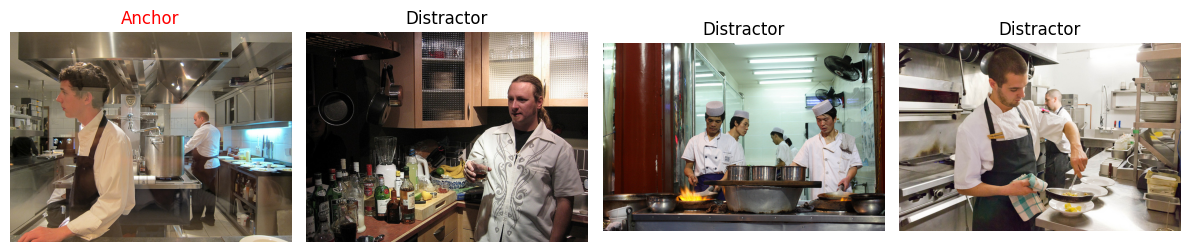

 22%|██▏       | 11/50 [00:03<00:16,  2.40it/s]

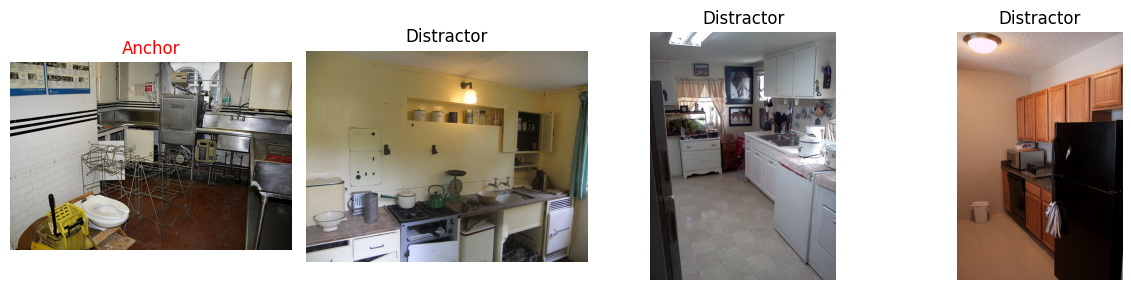

 44%|████▍     | 22/50 [00:06<00:06,  4.35it/s]

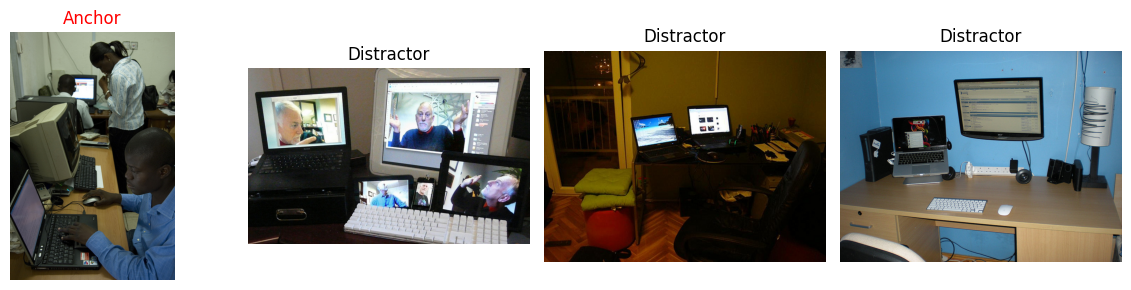

 50%|█████     | 25/50 [00:09<00:11,  2.14it/s]

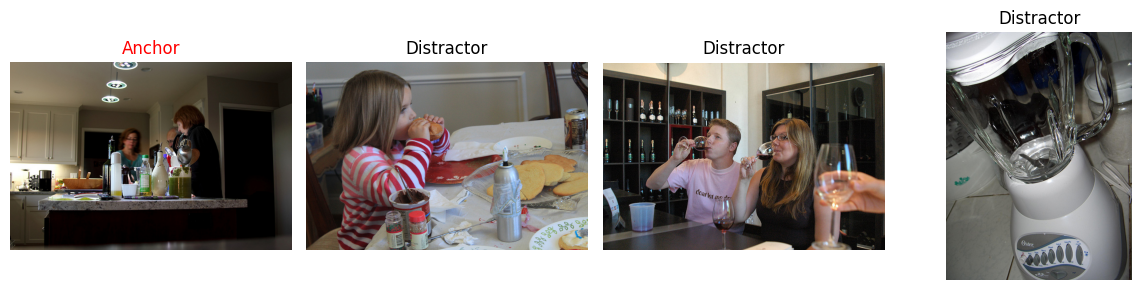

 54%|█████▍    | 27/50 [00:13<00:17,  1.33it/s]

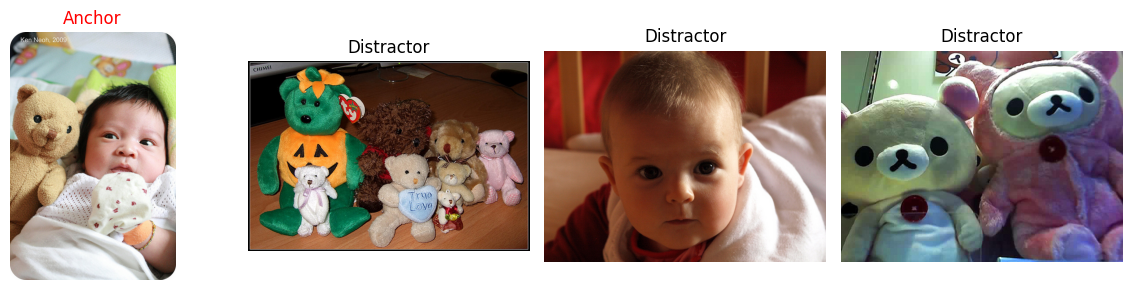

 94%|█████████▍| 47/50 [00:16<00:00,  6.61it/s]

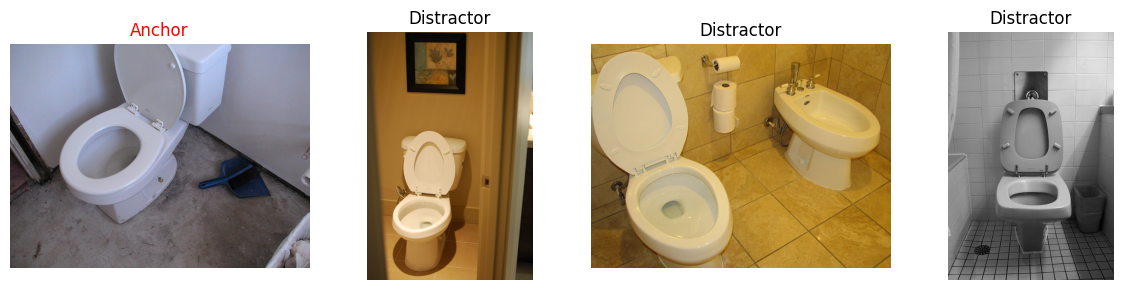

100%|██████████| 50/50 [00:19<00:00,  2.56it/s]

Avg anchor–distractor similarity: 0.8033
Avg top distractor similarity: 0.8184


In [13]:
n_distractors = 3
epoch = 0  # Set your curriculum learning epoch here
num_epochs = 5001
print('doing train data now: ')
for epoch in range(5000, num_epochs):
    # test_tuples, test_labels = create_exhaustive_tuples(np.array(ds_test["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    # valid_tuples, valid_labels = create_exhaustive_tuples(np.array(ds_val["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    # train_tuples, train_labels = create_exhaustive_tuples(np.array(ds_train["features"]), n_distractors=n_distractors, epoch=epoch, shuffle=True, seed=42)
    train_tuples, train_labels = create_pairwise_tuples(
        ds_train,
        n_distractors=3,
        epoch=epoch,
        shuffle=False,
        seed=42
    )
    valid_tuples, valid_labels = train_tuples, train_labels
    test_tuples, test_labels = train_tuples, train_labels
#     np.savez_compressed(
#     f"/home/elena/emcomm/emcomm_captions/winoground_epochs/data_{n_distractors}_distractors_{epoch}_epoch.npz",
#     train=train_tuples,
#     train_labels=train_labels,
#     valid=valid_tuples,
#     valid_labels=valid_labels,
#     test=test_tuples,
#     test_labels=test_labels,
#     n_distractors=3
# )



